# Interpretation

SHAP for direction and magnitude per feature, permutation importance for what the validation score actually depends on. LightGBM's native `pred_contrib` is used rather than `TreeExplainer`, which segfaults on macOS.

In [1]:
import sys; sys.path.append("..")
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import lightgbm as lgb
from src.data import INTERIM, ROOT
from src.models import time_split

FIGURES = ROOT / "figures"; FIGURES.mkdir(exist_ok=True)
CUTOFF, CATS = "2015-07-01", ["deviceID", "paymentMethod"]
DROP = ["orderID", "orderDate", "customerID", "any_return"]

def gbm():
    return lgb.LGBMClassifier(n_estimators=800, learning_rate=0.03, num_leaves=31, min_child_samples=50,
                              subsample=0.8, subsample_freq=1, colsample_bytree=0.7, reg_lambda=2.0,
                              n_jobs=-1, verbose=-1)

df = pd.read_parquet(INTERIM / "orders.parquet")
for block in ["basket", "customer", "article"]:
    df = df.merge(pd.read_parquet(INTERIM / f"{block}.parquet"), on="orderID", how="left")
FEATS = [c for c in df.columns if c not in DROP]
X = df[FEATS].copy()
for c in CATS:
    X[c] = X[c].astype("category")
y = df.any_return
tr, va = time_split(df, "orderDate", CUTOFF)
df.shape, len(FEATS)

((738698, 40), 36)

## Fit

**Refit and sample.** SHAP is computed on 20,000 validation rows rather than all 114,000 — enough for stable summary statistics at a fraction of the cost.

In [2]:
import matplotlib.pyplot as plt
import shap
m = gbm().fit(X[tr], y[tr])
SAMPLE = 20_000
samp = X[va].sample(SAMPLE, random_state=0)
samp.shape

(20000, 36)

## SHAP

**Native LightGBM SHAP.** `pred_contrib=True` returns one contribution per feature plus a bias column, which `[:, :-1]` drops. This path is used deliberately instead of `shap.TreeExplainer`, which segfaults on macOS — a hard crash, not a catchable exception.

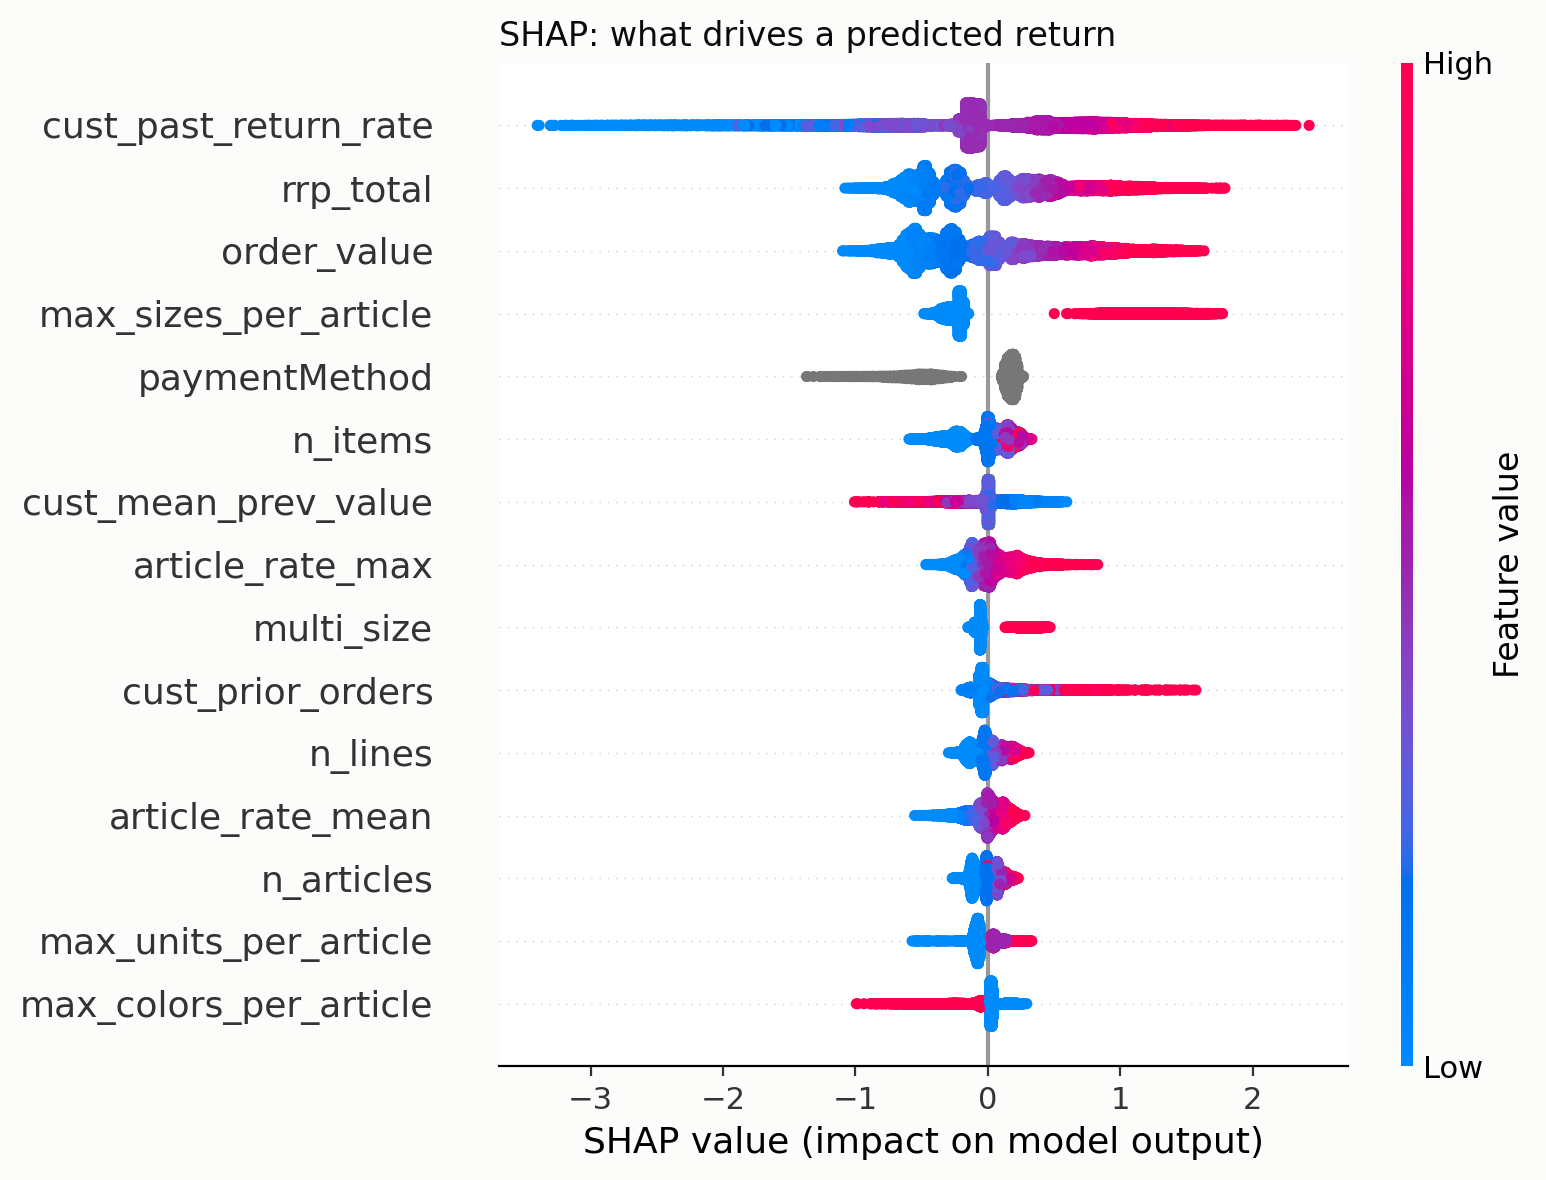

In [3]:
contrib = m.booster_.predict(samp, pred_contrib=True)[:, :-1]
shap.summary_plot(contrib, samp, max_display=15, show=False)
fig = plt.gcf(); fig.set_size_inches(8, 6); fig.set_dpi(200)
fig.patch.set_facecolor("#fcfcfb")
plt.title("SHAP: what drives a predicted return", fontsize=12, loc="left", color="#0b0b0b")
plt.tight_layout()
fig.savefig(FIGURES / "shap_summary.png", facecolor="#fcfcfb", bbox_inches="tight")
plt.show()

## Permutation importance

**Permutation importance.** Shuffle one column, measure how far validation AUC falls. Unlike LightGBM's split-gain, this measures what the *score* depends on rather than how often the tree happened to split on something, so it is not biased toward high-cardinality features.

In [4]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

sub = X[va].sample(20_000, random_state=1)
sub_y = y[va].loc[sub.index]
perm = permutation_importance(m, sub, sub_y, n_repeats=3, random_state=0, n_jobs=-1,
                              scoring="roc_auc")
pi = (pd.Series(perm.importances_mean, index=FEATS).sort_values(ascending=False).head(15))
pi.round(5)

cust_past_return_rate     0.08488
rrp_total                 0.01912
order_value               0.01889
max_sizes_per_article     0.01667
cust_prior_orders         0.00846
paymentMethod             0.00838
cust_mean_prev_value      0.00699
n_items                   0.00591
article_rate_max          0.00436
n_articles                0.00246
n_lines                   0.00194
article_rate_mean         0.00183
max_colors_per_article    0.00174
mean_discount             0.00100
max_units_per_article     0.00069
dtype: float64

**One series, one colour.** Bar length already encodes magnitude; colouring bars by their own value would double-encode it and waste the only free channel.

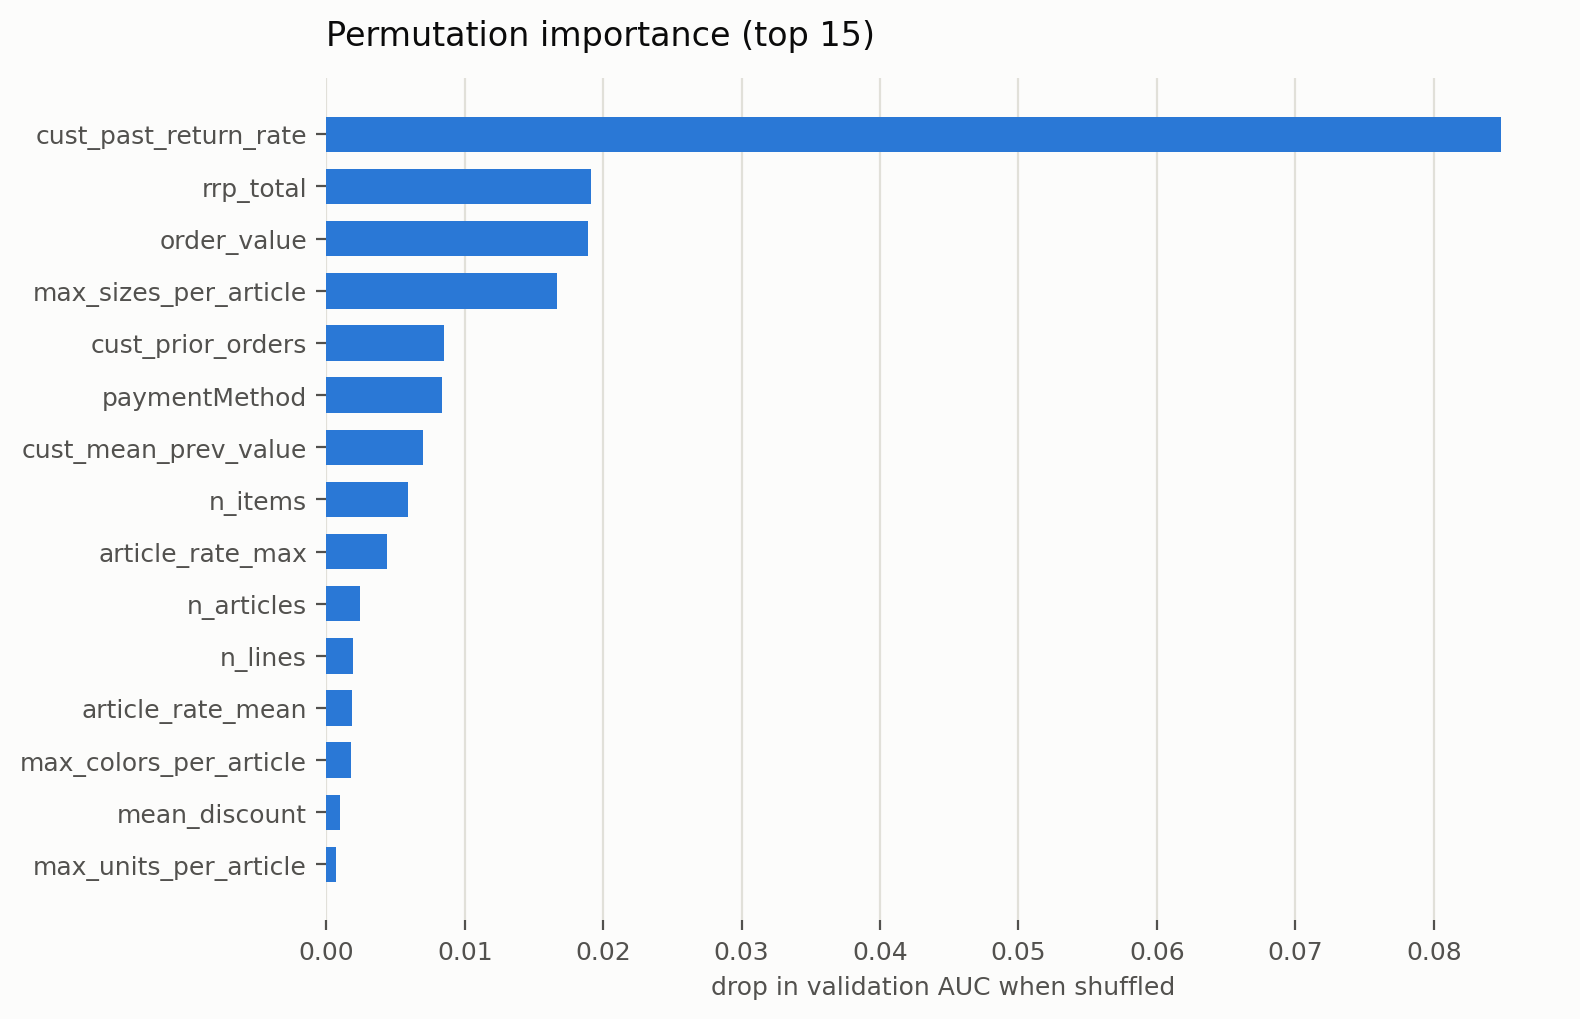

In [5]:
SURFACE, GRID, INK, MUTED, SLOT1 = "#fcfcfb", "#e1e0d9", "#0b0b0b", "#52514e", "#2a78d6"
fig, ax = plt.subplots(figsize=(8, 5.2), dpi=200)
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
order = pi.sort_values()
ax.barh(order.index, order.values, color=SLOT1, height=0.68, zorder=3)
ax.grid(True, axis="x", color=GRID, linewidth=0.8, linestyle="-", zorder=1)
ax.set_axisbelow(True)
for s in ax.spines.values(): s.set_visible(False)
ax.set_xlabel("drop in validation AUC when shuffled", color=MUTED, fontsize=9)
ax.set_title("Permutation importance (top 15)", color=INK, fontsize=12, pad=12, loc="left")
ax.tick_params(colors=MUTED, labelsize=9)
fig.tight_layout()
fig.savefig(FIGURES / "permutation_importance.png", facecolor=SURFACE, bbox_inches="tight")
plt.show()

## Save

**Persist the ranking.** Permutation importance is the version to trust for 'what does the score depend on', and the one to quote when someone asks which features matter.

In [6]:
pi.to_csv(INTERIM / "permutation_importance.csv")
pi.head(10).round(5)

cust_past_return_rate    0.08488
rrp_total                0.01912
order_value              0.01889
max_sizes_per_article    0.01667
cust_prior_orders        0.00846
paymentMethod            0.00838
cust_mean_prev_value     0.00699
n_items                  0.00591
article_rate_max         0.00436
n_articles               0.00246
dtype: float64